In [1]:
from extract_features import *

In [2]:
save_path = "Dados/Saída/"

In [3]:
ibge = gpd.read_file("zip://Dados/BR_Municipios_2024.zip!BR_Municipios_2024.shp")
ibge.plot()

DataSourceError: '/vsizip/Dados/BR_Municipios_2024.zip/BR_Municipios_2024.shp' does not exist in the file system, and is not recognized as a supported dataset name.

<Axes: >

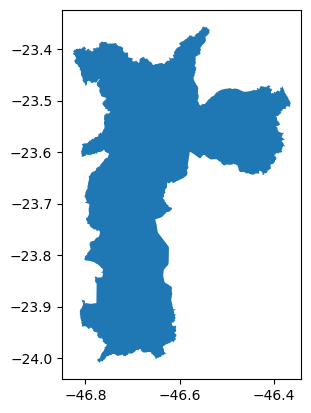

In [6]:
sp = ibge.loc[ibge["NM_MUN"] == "São Paulo"].copy()
sp.plot()

In [22]:
tags = {
    "amenity": ['school', 'community_centre', 'place_of_worship', 'clinic', 'hospital', 
                'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 
                'fast_food', 'bar', 'bus_station', 'waste_disposal', 'bicycle_parking'],
    "leisure": ['park', 'pitch', 'garden'],
    "shop": ['bakery', 'supermarket', 'convenience'],
    "landuse": ['allotments'],
    "railway": ['station'],
    "public_transport": ['station'],
    "highway": ['bus_stop', 'steps', 'street_lamp'],
    #"footway": ['sidewalk', 'crossing'],
    #"cycleway": ['lane'],
    "water": ['river']
    #"hazard": ['flooding']
}

In [23]:
# Loop through all keys
for key in ["amenity","leisure","shop", "landuse", "railway", "public_transport", "highway", "water"]:
    process_key(key, tags, sp, save_path, columns_to_show=[key,'name'])


Processing amenity...
Buscando por features com a tag 'amenity': 
['school', 'community_centre', 'place_of_worship', 'clinic', 'hospital', 'recycling', 'marketplace', 'kitchen', 'restaurant', 'cafe', 'fast_food', 'bar', 'bus_station', 'waste_disposal', 'bicycle_parking']

Quantidade original de features: 12912

Geometrias encontradas:
  - Polygons/MultiPolygons: 7005
  - Lines/MultiLines: 0

-> 8730 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_amenity.html
Parquet saved: Dados/Saída/features_amenity.parquet
PMTiles saved: Dados/Saída/features_amenity.pmtiles
✓ Completed amenity


Processing leisure...
Buscando por features com a tag 'leisure': 
['park', 'pitch', 'garden']

Quantidade original de features: 14953

Geometrias encontradas:
  - Polygons/MultiPolygons: 14803
  - Lines/MultiLines: 0

-> 11006 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_leisure.html
Parquet sav

c:\Users\9837292\Documents\GitHub\etl_osm\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: At least one tile exceeded the default maximum tile size of 500000 bytes and was encoded at lower resolution
  ogr_write(


PMTiles saved: Dados/Saída/features_highway.pmtiles
✓ Completed highway


Processing water...
Buscando por features com a tag 'water': 
['river']

Quantidade original de features: 74

Geometrias encontradas:
  - Polygons/MultiPolygons: 73
  - Lines/MultiLines: 1

-> 35 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_water.html
Parquet saved: Dados/Saída/features_water.parquet
PMTiles saved: Dados/Saída/features_water.pmtiles
✓ Completed water



In [ ]:
# Define the specific values for the directional keys
directional_cycleway_values = [
    "yes", 
    "lane", 
    "track", 
    "shoulder", 
    "shared", 
    "shared_lane", 
    "share_busway", 
    "shared_parking_lane"
]

bike_tags = {
    # Primary infrastructure
    "highway": ["cycleway"],
    "bicycle": ["designated","yes"],
    "bicycle_road": ["yes"],
    "cyclestreet": ["yes"],
    
    # On-street cycleway tags (including legacy tags)
    "cycleway": [
        "lane", "shared_lane", "share_busway", "track", 
        "opposite", "opposite_lane", "opposite_share_busway", "opposite_track"
    ],
    
    # Directional side tags using the specific values
    "cycleway:left": directional_cycleway_values,
    "cycleway:right": directional_cycleway_values,
    "cycleway:both": directional_cycleway_values
}

In [28]:
bike_features = process_key(
    tags=bike_tags, 
    city_geom=sp, 
    save_path=save_path, 
    columns_to_show=['highway','bicycle','bicycle_road','cyclestreet', 'cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both', 'name'], 
    tags_name="bike_tags",
    use_custom_type=True
)



Processing all tags (bike_tags)...
Buscando por features para todas as tags...

Quantidade original de features: 8761

Geometrias encontradas:
  - Polygons/MultiPolygons: 3
  - Lines/MultiLines: 8744

-> 14608 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_bike_tags.html
Parquet saved: Dados/Saída/features_bike_tags.parquet
PMTiles saved: Dados/Saída/features_bike_tags.pmtiles
✓ Completed processing all tags



In [ ]:
footway_tags = {
    "highway": ["footway", "pedestrian", "corridor"],#, "path", "steps"],
    "footway": ["sidewalk", "crossing"],
    "foot": ["designated", "yes"],
    #"area:highway": ["footway"],
    #"area": ["yes"],
    "informal": ["yes"]
}

In [ ]:
process_key(tags=footway_tags, city_geom=sp, save_path=save_path, columns_to_show=[list(footway_tags.keys()),'name'], tags_name="footway_tags")


Processing all tags (footway_tags)...
Buscando por features para todas as tags...

Quantidade original de features: 50522

Geometrias encontradas:
  - Polygons/MultiPolygons: 202
  - Lines/MultiLines: 50100

-> 69565 features mantidas dentro dos limites da cidade após processamento.

Map saved: docs/mapas/features_map_footway_tags.html
Parquet saved: Dados/Saída/features_footway_tags.parquet


c:\Users\9837292\Documents\GitHub\etl_osm\.venv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: At least one tile exceeded the default maximum tile size of 500000 bytes and was encoded at lower resolution
  ogr_write(


PMTiles saved: Dados/Saída/features_footway_tags.pmtiles
✓ Completed processing all tags



,geometry,highway,maxspeed,crossing,crossing:markings,crossing_ref,button_operated,traffic_signals:sound,traffic_signals:vibration,traffic_signals,...,parking:condition:right,device,lines,house,driving_side,type,paving_stones:length,station,reservation,_key
0,POINT (-46.71177 -23.57524),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foot
1,POINT (-46.71244 -23.56329),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foot
2,POINT (-46.67295 -23.5575),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foot
3,POINT (-46.65827 -23.5601),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foot
4,POINT (-46.65907 -23.5608),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,foot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100617,POINT (-46.64317 -23.54817),footway,NaN,traffic_signals,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,highway
100618,POINT (-46.6429 -23.54802),footway,NaN,traffic_signals,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,highway
100619,POINT (-46.64271 -23.54814),footway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,highway
100620,POINT (-46.53912 -23.53113),footway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,highway
